# NB03 — Data Preprocessing & Emoji Graph Construction
## EPGT Research Pipeline | Emoji Pragmatic Graph Transformer

---

### Tujuan Notebook

Notebook ini mengimplementasikan dua pipeline utama sebelum data masuk ke model:

**Tahap 1 — 7-Stage Text Preprocessing Pipeline**
1. Unicode normalization (NFKC)
2. Emoji extraction (pada raw text, sebelum cleaning)
3. Text normalization (URL, mention, repeated chars, punctuation)
4. IndoBERT tokenization (max_length=128, padding, attention mask)
5. Inclusion filter verification
6. Feature engineering (emoji positions, repetition flags, sentiment scores)
7. Save processed features ke Drive

**Tahap 2 — Emoji Pragmatic Graph Construction**
Membangun graph G=(V,E,W) per sampel:
- Node: satu node per emoji token dengan feature vector x_i ∈ ℝ²⁰³
- Edge: 3 tipe (Sequential, Repetition, Semantic) dengan weight function
- Output: PyTorch Geometric `Data` objects disimpan sebagai pickle

---

### Output
```
EPGT_Research/data/features/
├── text_embeddings/  train_embeddings.pt, val_embeddings.pt, test_embeddings.pt
├── emoji_features/   train_emoji.pkl, val_emoji.pkl, test_emoji.pkl
└── graph_objects/    train_graphs.pkl, val_graphs.pkl, test_graphs.pkl
```

**Blueprint Reference:** Section 2.2 Preprocessing Pipeline, Section 3.2 Emoji Graph Encoder

---
## BAGIAN 1 — ENVIRONMENT SETUP

In [1]:
# ============================================================
# CELL 1.1 — Install Dependencies
# ============================================================

print("Installing dependencies...")

!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torch-geometric
!pip install -q transformers
!pip install -q emoji
!pip install -q pandas numpy tqdm scikit-learn
!pip install -q gensim   # untuk emoji2vec fallback

print("\nAll dependencies installed.")

# Verifikasi GPU
import torch
print(f"\nPyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device          : {DEVICE}")

Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.2 MB/s eta 0:00:00

All dependencies installed.

PyTorch version : 2.10.0+cpu
CUDA available  : False
Device          : cpu


In [3]:
# ============================================================
# CELL 1.2 — Mount Drive & Setup Path
# ============================================================

from google.colab import drive
import sys
from pathlib import Path

drive.mount("/content/drive")

DRIVE_ROOT   = Path("/content/drive/MyDrive/EPGT_Research")
RUNTIME_ROOT = Path("/content/EPGT_runtime")
SRC_PATH     = str(DRIVE_ROOT / "src")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Verifikasi output NB02
import pandas as pd
splits_ok = all(
    (DRIVE_ROOT / "data/processed" / f).exists()
    for f in ["train.csv", "val.csv", "test.csv"]
)
print(f"NB02 splits available : {splits_ok}")
if splits_ok:
    df_train = pd.read_csv(DRIVE_ROOT / "data/processed/train.csv")
    df_val   = pd.read_csv(DRIVE_ROOT / "data/processed/val.csv")
    df_test  = pd.read_csv(DRIVE_ROOT / "data/processed/test.csv")
    print(f"Train : {len(df_train):,} | Val : {len(df_val):,} | Test : {len(df_test):,}")
else:
    print("WARNING: Jalankan NB02 terlebih dahulu.")

RANDOM_SEED = 42

Mounted at /content/drive
NB02 splits available : True
Train : 56 | Val : 12 | Test : 12


---
## BAGIAN 2 — PREPROCESSING MODULE (src/data/preprocessor.py)

In [4]:
# ============================================================
# CELL 2.1 — Tulis preprocessor.py ke src/data/
# ============================================================

PREPROCESSOR_CODE = '''"""
preprocessor.py — 7-Stage Text Preprocessing Pipeline untuk EPGT.

Stage 1 : Unicode normalization (NFKC)
Stage 2 : Emoji extraction (pada raw text, sebelum cleaning)
Stage 3 : Text normalization (URL, mention, repeated chars)
Stage 4 : IndoBERT tokenization (max_length=128)
Stage 5 : Inclusion filter verification
Stage 6 : Feature engineering (positions, repetition, sentiment)
Stage 7 : Batch processing + save
"""

import re
import unicodedata
import logging
import numpy as np
import pandas as pd
import emoji
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from transformers import AutoTokenizer

logger = logging.getLogger(__name__)


# ── STAGE 1 & 3: Text Normalizer ─────────────────────────────────────────────

class IndonesianTextNormalizer:
    """
    Normalisasi teks Indonesia untuk NLP.
    Urutan operasi penting: emoji diekstrak DULU sebelum normalisasi.
    """

    def __init__(self):
        self._emoji_pat = re.compile(
            "(" + "|".join(
                re.escape(e)
                for e in sorted(emoji.EMOJI_DATA.keys(), key=len, reverse=True)
            ) + ")"
        )
        # Patterns normalisasi
        self._url_pat       = re.compile(r"https?://\\S+|www\\.\\S+")
        self._mention_pat   = re.compile(r"@\\w+")
        self._hashtag_pat   = re.compile(r"#(\\w+)")
        self._repeated_char = re.compile(r"(.)\\1{2,}")
        self._repeated_punc = re.compile(r"([!?.]){2,}")
        self._whitespace    = re.compile(r"\\s+")

    def normalize_unicode(self, text: str) -> str:
        """Stage 1: Unicode NFKC normalization."""
        return unicodedata.normalize("NFKC", text)

    def extract_emojis(self, text: str) -> List[str]:
        """Stage 2: Ekstrak emoji dari raw text (sebelum normalisasi)."""
        return self._emoji_pat.findall(text)

    def remove_emojis(self, text: str) -> str:
        """Hapus emoji dari teks."""
        return self._emoji_pat.sub(" ", text)

    def normalize_text(self, text: str) -> str:
        """
        Stage 3: Normalisasi teks.
        Urutan: URL → mention → hashtag → repeated chars → whitespace
        Emoji sudah dihapus sebelum fungsi ini dipanggil.
        """
        text = text.lower()
        text = self._url_pat.sub("", text)               # hapus URL
        text = self._mention_pat.sub("", text)           # hapus @mention
        text = self._hashtag_pat.sub(r"\\1", text)      # #kata → kata
        text = self._repeated_char.sub(r"\\1\\1", text) # bangettt → bangett
        text = self._repeated_punc.sub(r"\\1", text)    # !!! → !
        text = self._whitespace.sub(" ", text).strip()  # whitespace
        return text

    def get_emoji_positions(
        self,
        text: str,
        emojis: List[str],
    ) -> List[float]:
        """
        Hitung posisi normalized tiap emoji dalam teks.
        Normalized position = char_position / len(text)
        Sesuai blueprint: p_i ∈ ℝ¹
        """
        if not text or not emojis:
            return []

        positions = []
        search_start = 0

        for e in emojis:
            idx = text.find(e, search_start)
            if idx == -1:
                idx = text.find(e, 0)
            if idx != -1:
                normalized_pos = idx / max(len(text), 1)
                positions.append(round(normalized_pos, 6))
                search_start = idx + len(e)
            else:
                positions.append(0.0)

        return positions

    def get_repetition_flags(self, emojis: List[str]) -> List[int]:
        """
        Hitung repetition flag r_i untuk tiap emoji.
        r_i = 1 jika emoji_i == emoji_{i-1}, else 0.
        Sesuai blueprint: r_i ∈ ℝ¹
        """
        if not emojis:
            return []
        flags = [0]  # emoji pertama tidak bisa berulang
        for i in range(1, len(emojis)):
            flags.append(1 if emojis[i] == emojis[i-1] else 0)
        return flags

    def process(self, text: str) -> Dict:
        """
        Full preprocessing satu sampel.
        Returns dict dengan semua field yang dibutuhkan graph builder.
        """
        # Stage 1: Unicode
        text_unicode = self.normalize_unicode(str(text))

        # Stage 2: Ekstrak emoji dari raw text
        emojis        = self.extract_emojis(text_unicode)
        emoji_count   = len(emojis)
        emoji_sequence= ",".join(emojis)

        # Stage 3: Normalisasi teks (hapus emoji dulu)
        text_no_emoji = self.remove_emojis(text_unicode)
        cleaned_text  = self.normalize_text(text_no_emoji)

        # Stage 6: Feature engineering
        emoji_positions   = self.get_emoji_positions(text_unicode, emojis)
        repetition_flags  = self.get_repetition_flags(emojis)

        return {
            "raw_text"         : text,
            "cleaned_text"     : cleaned_text,
            "emoji_sequence"   : emoji_sequence,
            "emoji_count"      : emoji_count,
            "emoji_list"       : emojis,
            "emoji_positions"  : emoji_positions,
            "repetition_flags" : repetition_flags,
        }


# ── STAGE 4: IndoBERT Tokenizer ───────────────────────────────────────────────

class EPGTTokenizer:
    """
    Wrapper IndoBERT tokenizer untuk EPGT.
    Model: indobenchmark/indobert-base-p1
    Fallback: bert-base-multilingual-cased
    Output: input_ids, attention_mask, token_type_ids (max_length=128)
    """

    PRIMARY_MODEL  = "indobenchmark/indobert-base-p1"
    FALLBACK_MODEL = "bert-base-multilingual-cased"

    def __init__(self, max_length: int = 128):
        self.max_length = max_length
        self.tokenizer  = self._load_tokenizer()

    def _load_tokenizer(self) -> AutoTokenizer:
        for model_name in [self.PRIMARY_MODEL, self.FALLBACK_MODEL]:
            try:
                tok = AutoTokenizer.from_pretrained(model_name)
                logger.info(f"Tokenizer loaded: {model_name}")
                print(f"  Tokenizer: {model_name}")
                return tok
            except Exception as e:
                logger.warning(f"Failed to load {model_name}: {e}")
        raise RuntimeError("Semua tokenizer gagal dimuat.")

    def tokenize(self, text: str) -> Dict:
        """
        Tokenize satu teks.
        Returns: input_ids, attention_mask, token_type_ids (semua list int)
        """
        encoded = self.tokenizer(
            text,
            max_length      = self.max_length,
            padding         = "max_length",
            truncation      = True,
            return_tensors  = None,
        )
        return {
            "input_ids"      : encoded["input_ids"],
            "attention_mask" : encoded["attention_mask"],
            "token_type_ids" : encoded.get("token_type_ids", [0] * self.max_length),
        }

    def tokenize_batch(
        self,
        texts     : List[str],
        batch_size: int = 64,
    ) -> Dict[str, List]:
        """
        Tokenize batch teks secara efisien.
        Returns dict of lists: input_ids, attention_mask, token_type_ids
        """
        from tqdm.auto import tqdm
        all_input_ids       = []
        all_attention_masks = []
        all_token_type_ids  = []

        for i in tqdm(range(0, len(texts), batch_size), desc="Tokenizing"):
            batch = texts[i : i + batch_size]
            encoded = self.tokenizer(
                batch,
                max_length      = self.max_length,
                padding         = "max_length",
                truncation      = True,
                return_tensors  = None,
            )
            all_input_ids.extend(encoded["input_ids"])
            all_attention_masks.extend(encoded["attention_mask"])
            all_token_type_ids.extend(
                encoded.get("token_type_ids", [[0]*self.max_length]*len(batch))
            )

        return {
            "input_ids"      : all_input_ids,
            "attention_mask" : all_attention_masks,
            "token_type_ids" : all_token_type_ids,
        }


# ── FULL PIPELINE ─────────────────────────────────────────────────────────────

class EPGTPreprocessor:
    """
    Orkestrasi 7-stage preprocessing pipeline.
    Input : DataFrame dengan kolom 'text'
    Output: DataFrame dengan semua feature columns + tokenization
    """

    def __init__(self, max_length: int = 128):
        self.normalizer = IndonesianTextNormalizer()
        self.tokenizer  = EPGTTokenizer(max_length=max_length)
        self.max_length = max_length

    def process_dataframe(
        self,
        df          : pd.DataFrame,
        text_col    : str = "text",
        batch_size  : int = 64,
        show_progress: bool = True,
    ) -> pd.DataFrame:
        """
        Proses seluruh DataFrame melalui 7-stage pipeline.

        Returns:
            DataFrame dengan tambahan kolom:
              cleaned_text, emoji_sequence, emoji_count,
              emoji_list, emoji_positions, repetition_flags,
              input_ids, attention_mask, token_type_ids
        """
        from tqdm.auto import tqdm

        result = df.copy()

        # Stage 1-2-3-6: Normalisasi + feature engineering
        print("Stage 1-3-6: Text normalization + emoji extraction...")
        processed_rows = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing",
                           disable=not show_progress):
            proc = self.normalizer.process(str(row.get(text_col, "")))
            processed_rows.append(proc)

        proc_df = pd.DataFrame(processed_rows)

        # Update kolom yang sudah ada di df atau tambahkan yang baru
        for col in ["cleaned_text", "emoji_sequence", "emoji_count",
                    "emoji_list", "emoji_positions", "repetition_flags"]:
            if col in proc_df.columns:
                result[col] = proc_df[col].values

        # Stage 4: Tokenisasi cleaned_text
        print("Stage 4: IndoBERT tokenization...")
        cleaned_texts = result["cleaned_text"].fillna("").tolist()
        token_data    = self.tokenizer.tokenize_batch(
            cleaned_texts,
            batch_size=batch_size,
        )
        result["input_ids"]       = token_data["input_ids"]
        result["attention_mask"]  = token_data["attention_mask"]
        result["token_type_ids"]  = token_data["token_type_ids"]

        # Stage 5: Inclusion filter — drop samples yang tidak memenuhi syarat
        before = len(result)
        result = result[result["emoji_count"] >= 1].reset_index(drop=True)
        after  = len(result)
        if before != after:
            logger.warning(f"Stage 5 filter: removed {before-after} samples without emoji")
            print(f"Stage 5: Filtered {before-after} samples (no emoji)")
        else:
            print(f"Stage 5: All {after} samples passed inclusion filter")

        print(f"Preprocessing complete: {len(result):,} samples")
        return result
'''

preprocessor_path = DRIVE_ROOT / "src/data/preprocessor.py"
preprocessor_path.write_text(PREPROCESSOR_CODE, encoding="utf-8")
print(f"preprocessor.py saved: {preprocessor_path}")
print(f"Size: {preprocessor_path.stat().st_size:,} bytes")

preprocessor.py saved: /content/drive/MyDrive/EPGT_Research/src/data/preprocessor.py
Size: 11,190 bytes


---
## BAGIAN 3 — EMOJI GRAPH MODULE (src/features/emoji_graph.py)

In [5]:
# ============================================================
# CELL 3.1 — Tulis emoji_graph.py ke src/features/
# ============================================================
# Implementasi Emoji Pragmatic Graph G=(V,E,W)
# Sesuai blueprint Section 3.2 Emoji Structural Graph Encoder
#
# Node feature vector: x_i = Concat(e_i, p_i, s_i, r_i) ∈ ℝ²⁰³
#   e_i ∈ ℝ²⁰⁰ : emoji identity embedding (emoji2vec / random fallback)
#   p_i ∈ ℝ¹   : normalized position
#   s_i ∈ ℝ¹   : sentiment polarity score
#   r_i ∈ ℝ¹   : repetition flag
#
# 3 Edge types:
#   Sequential  : v_i → v_{i+1}, w = 1/(1+|pos_i - pos_j|)
#   Repetition  : v_i → v_j (same emoji, |i-j|≤K=3), w = count/K
#   Semantic    : v_i → v_j (cosine_sim(s_i,s_j) ≥ θ=0.7)

EMOJI_GRAPH_CODE = '''"""
emoji_graph.py — Emoji Pragmatic Graph Constructor untuk EPGT.

Membangun G=(V,E,W) sesuai blueprint Section 3.2:
  Node feature: x_i = Concat(e_i∈ℝ²⁰⁰, p_i∈ℝ¹, s_i∈ℝ¹, r_i∈ℝ¹) ∈ ℝ²⁰³
  Edge types  : Sequential, Repetition, Semantic
  Output      : torch_geometric.data.Data object
"""

import re
import logging
import numpy as np
import torch
import emoji
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from torch_geometric.data import Data

logger = logging.getLogger(__name__)

# ── KONSTANTA ─────────────────────────────────────────────────────────────────
EMOJI_EMBEDDING_DIM   = 200     # e_i dimensi
NODE_FEATURE_DIM      = 203     # total: 200 + 1 + 1 + 1
REPETITION_WINDOW_K   = 3       # window untuk repetition edge
SEMANTIC_THRESHOLD    = 0.7     # threshold cosine similarity semantic edge

# Edge type encoding
EDGE_TYPE_SEQUENTIAL  = 0
EDGE_TYPE_REPETITION  = 1
EDGE_TYPE_SEMANTIC    = 2


# ── EMOJI SENTIMENT LEXICON ───────────────────────────────────────────────────

class EmojiSentimentLexicon:
    """
    Sentiment polarity score s_i untuk tiap emoji.
    Sumber: EmojiNet-inspired manual mapping.
    Score range: [-1.0, 1.0]
    Default: 0.0 (netral) untuk emoji tidak dikenal.
    """

    SENTIMENT_MAP = {
        # Positif kuat (+0.8 s/d +1.0)
        "\U0001F525": 0.9,   # 🔥
        "\U0001F60D": 1.0,   # 😍
        "\U0001F929": 1.0,   # 🤩
        "\U0001F970": 0.9,   # 🥰
        "\U0001F4AF": 0.9,   # 💯
        "\u2764":    0.8,    # ❤
        "\U0001F496": 0.8,   # 💖
        "\U0001F44F": 0.8,   # 👏
        "\U0001F44D": 0.7,   # 👍
        "\U0001F64F": 0.7,   # 🙏
        "\U0001F31F": 0.8,   # 🌟
        "\U0001F38A": 0.7,   # 🎊
        "\U0001F389": 0.7,   # 🎉
        # Positif sedang (+0.3 s/d +0.7)
        "\U0001F602": 0.7,   # 😂
        "\U0001F923": 0.6,   # 🤣
        "\U0001F604": 0.6,   # 😄
        "\U0001F600": 0.5,   # 😀
        "\U0001F609": 0.5,   # 😉
        "\U0001F618": 0.6,   # 😘
        "\U0001F31E": 0.6,   # 🌞
        "\U0001F33F": 0.4,   # 🌿
        "\U0001FAB4": 0.4,   # 🪴
        # Netral (sekitar 0.0)
        "\U0001F914": 0.0,   # 🤔
        "\U0001F440": 0.0,   # 👀
        "\U0001F4AC": 0.0,   # 💬
        "\U0001F4DD": 0.0,   # 📝
        "\U0001F44B": 0.1,   # 👋
        # Negatif sedang (-0.3 s/d -0.7)
        "\U0001F614": -0.4,  # 😔
        "\U0001F615": -0.3,  # 😕
        "\U0001F62C": -0.5,  # 😬
        "\U0001F611": -0.4,  # 😑
        "\U0001F644": -0.4,  # 🙄
        "\U0001F624": -0.5,  # 😤
        "\U0001F621": -0.7,  # 😡
        "\U0001F620": -0.6,  # 😠
        # Negatif kuat / ironi (-0.7 s/d -1.0)
        "\U0001F62D": -0.7,  # 😭
        "\U0001F480": -0.8,  # 💀
        "\U0001F5FF": -0.6,  # 🗿 (ironi/sarkasme)
        "\U0001F642": -0.5,  # 🙂 (ironi implisit)
        "\U0001F921": -0.6,  # 🤡
        "\U0001FAE0": -0.5,  # 🫠
        "\U0001F494": -0.9,  # 💔
        "\U0001F629": -0.8,  # 😩
    }

    def get_score(self, emoji_char: str) -> float:
        return self.SENTIMENT_MAP.get(emoji_char, 0.0)

    def get_scores(self, emojis: List[str]) -> List[float]:
        return [self.get_score(e) for e in emojis]


# ── EMOJI EMBEDDING LOADER ────────────────────────────────────────────────────

class EmojiEmbeddingLoader:
    """
    Loader untuk emoji identity embedding e_i ∈ ℝ²⁰⁰.
    Prioritas: (1) pre-trained emoji2vec → (2) random init
    Random init: seeded hash dari unicode codepoint untuk konsistensi.
    """

    def __init__(self, embedding_dim: int = 200):
        self.embedding_dim = embedding_dim
        self._cache: Dict[str, np.ndarray] = {}

    def get_embedding(self, emoji_char: str) -> np.ndarray:
        """
        Ambil embedding untuk satu emoji.
        Menggunakan seeded random berdasarkan unicode codepoint
        untuk menghasilkan embedding yang konsisten dan deterministik.
        """
        if emoji_char in self._cache:
            return self._cache[emoji_char]

        # Seed dari hash unicode codepoint → deterministik & konsisten
        seed = sum(ord(c) for c in emoji_char) % (2**31)
        rng  = np.random.RandomState(seed)
        emb  = rng.randn(self.embedding_dim).astype(np.float32)

        # L2 normalize
        norm = np.linalg.norm(emb)
        if norm > 0:
            emb = emb / norm

        self._cache[emoji_char] = emb
        return emb

    def get_embeddings(self, emojis: List[str]) -> np.ndarray:
        """
        Returns: array of shape (n_emoji, embedding_dim)
        """
        if not emojis:
            return np.zeros((0, self.embedding_dim), dtype=np.float32)
        return np.stack([self.get_embedding(e) for e in emojis])


# ── GRAPH BUILDER ─────────────────────────────────────────────────────────────

class EmojiGraphBuilder:
    """
    Membangun Emoji Pragmatic Graph G=(V,E,W) sesuai blueprint.

    Node feature x_i = Concat(e_i, p_i, s_i, r_i) ∈ ℝ²⁰³:
      e_i ∈ ℝ²⁰⁰ : identity embedding
      p_i ∈ ℝ¹   : normalized position = token_pos / seq_len
      s_i ∈ ℝ¹   : sentiment score ∈ [-1, 1]
      r_i ∈ ℝ¹   : repetition flag ∈ {0, 1}

    Edge types:
      0 = Sequential  : v_i → v_{i+1}
      1 = Repetition  : v_i → v_j (same emoji, |i-j| ≤ K=3)
      2 = Semantic    : v_i → v_j (cosine_sim ≥ θ=0.7)
    """

    def __init__(
        self,
        embedding_dim    : int   = EMOJI_EMBEDDING_DIM,
        repetition_window: int   = REPETITION_WINDOW_K,
        semantic_threshold: float = SEMANTIC_THRESHOLD,
    ):
        self.embedding_dim     = embedding_dim
        self.K                 = repetition_window
        self.theta             = semantic_threshold
        self.emb_loader        = EmojiEmbeddingLoader(embedding_dim)
        self.sentiment_lexicon = EmojiSentimentLexicon()

    def _cosine_similarity(self, a: np.ndarray, b: np.ndarray) -> float:
        norm_a = np.linalg.norm(a)
        norm_b = np.linalg.norm(b)
        if norm_a == 0 or norm_b == 0:
            return 0.0
        return float(np.dot(a, b) / (norm_a * norm_b))

    def build_node_features(
        self,
        emojis           : List[str],
        positions        : List[float],
        repetition_flags : List[int],
        zero_position    : bool = False,
    ) -> torch.Tensor:
        """
        Bangun node feature matrix X ∈ ℝ^{n×203}.

        Args:
            zero_position: Jika True, set p_i=0 (untuk ablation ABL-4)

        Returns:
            Tensor shape (n_emoji, 203)
        """
        n = len(emojis)
        if n == 0:
            return torch.zeros((1, NODE_FEATURE_DIM), dtype=torch.float)

        # e_i: identity embeddings (n, 200)
        emb_matrix = self.emb_loader.get_embeddings(emojis)

        # p_i: normalized position (n, 1)
        pos_array = np.zeros((n, 1), dtype=np.float32)
        if not zero_position and positions:
            for i, p in enumerate(positions[:n]):
                pos_array[i, 0] = float(p)

        # s_i: sentiment score (n, 1)
        scores    = self.sentiment_lexicon.get_scores(emojis)
        sent_array= np.array(scores[:n], dtype=np.float32).reshape(-1, 1)

        # r_i: repetition flag (n, 1)
        rep_flags = repetition_flags[:n] if repetition_flags else [0] * n
        rep_array = np.array(rep_flags, dtype=np.float32).reshape(-1, 1)

        # Concatenate: (n, 200+1+1+1) = (n, 203)
        x = np.concatenate([emb_matrix, pos_array, sent_array, rep_array], axis=1)
        return torch.tensor(x, dtype=torch.float)

    def build_edges(
        self,
        emojis           : List[str],
        positions        : List[float],
        node_features    : torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Bangun edge_index, edge_weight, edge_type.

        Returns:
            edge_index  : LongTensor (2, E)
            edge_weight : FloatTensor (E,)
            edge_type   : LongTensor (E,)
        """
        n          = len(emojis)
        src_list   = []
        dst_list   = []
        weight_list= []
        type_list  = []

        # EDGE TYPE 0: Sequential v_i → v_{i+1}
        # w_seq = 1 / (1 + |pos_i - pos_j|)
        for i in range(n - 1):
            j   = i + 1
            p_i = positions[i] if i < len(positions) else 0.0
            p_j = positions[j] if j < len(positions) else 0.0
            w   = 1.0 / (1.0 + abs(p_i - p_j))
            src_list.append(i);    dst_list.append(j)
            weight_list.append(w); type_list.append(EDGE_TYPE_SEQUENTIAL)

        # EDGE TYPE 1: Repetition v_i → v_j (same emoji, |i-j| ≤ K)
        # w_rep = count(emoji_i in window) / K
        for i in range(n):
            window_start = max(0, i - self.K)
            window_end   = min(n, i + self.K + 1)
            same_in_window = sum(
                1 for j in range(window_start, window_end)
                if j != i and emojis[j] == emojis[i]
            )
            if same_in_window > 0:
                w = same_in_window / self.K
                for j in range(window_start, window_end):
                    if j != i and emojis[j] == emojis[i]:
                        src_list.append(i);    dst_list.append(j)
                        weight_list.append(w); type_list.append(EDGE_TYPE_REPETITION)

        # EDGE TYPE 2: Semantic v_i → v_j (cosine_sim(s_i, s_j) ≥ θ)
        # w_sem = cosine_sim(s_i, s_j)
        # Gunakan embedding vector untuk menghitung similarity
        nf = node_features.numpy()
        for i in range(n):
            for j in range(n):
                if i == j:
                    continue
                e_i = nf[i, :self.embedding_dim]
                e_j = nf[j, :self.embedding_dim]
                sim = self._cosine_similarity(e_i, e_j)
                if sim >= self.theta:
                    src_list.append(i);      dst_list.append(j)
                    weight_list.append(sim); type_list.append(EDGE_TYPE_SEMANTIC)

        if not src_list:
            # Tidak ada edge → kembalikan tensor kosong
            return (
                torch.zeros((2, 0), dtype=torch.long),
                torch.zeros((0,),   dtype=torch.float),
                torch.zeros((0,),   dtype=torch.long),
            )

        edge_index  = torch.tensor([src_list, dst_list], dtype=torch.long)
        edge_weight = torch.tensor(weight_list,          dtype=torch.float)
        edge_type   = torch.tensor(type_list,            dtype=torch.long)

        return edge_index, edge_weight, edge_type

    def build_graph(
        self,
        emojis           : List[str],
        positions        : List[float],
        repetition_flags : List[int],
        label_intensity  : int = -1,
        label_sarcasm    : int = -1,
        label_emoji_role : int = -1,
        sample_id        : str = "",
        ablation_mode    : Optional[str] = None,
    ) -> Data:
        """
        Bangun satu PyG Data object.

        Args:
            ablation_mode: None | "no_position" (ABL-4: zero p_i)

        Returns:
            torch_geometric.data.Data dengan:
              x           : node features (n, 203)
              edge_index  : (2, E)
              edge_weight : (E,)
              edge_type   : (E,)
              num_nodes   : n
              y_intensity : label tensor
              y_sarcasm   : label tensor
              y_role      : label tensor
        """
        # Handle edge case: tidak ada emoji
        if not emojis:
            emojis           = ["\U0001F610"]  # 😐 placeholder
            positions        = [0.5]
            repetition_flags = [0]

        # Handle single emoji → self-loop
        add_self_loop = len(emojis) == 1

        zero_pos   = ablation_mode == "no_position"
        x          = self.build_node_features(emojis, positions, repetition_flags, zero_pos)
        edge_index, edge_weight, edge_type = self.build_edges(emojis, positions, x)

        # Self-loop untuk single emoji
        if add_self_loop or edge_index.shape[1] == 0:
            n          = x.shape[0]
            self_loops = torch.arange(n).unsqueeze(0).repeat(2, 1)
            self_wts   = torch.ones(n, dtype=torch.float)
            self_types = torch.zeros(n, dtype=torch.long)
            if edge_index.shape[1] > 0:
                edge_index  = torch.cat([edge_index,  self_loops], dim=1)
                edge_weight = torch.cat([edge_weight, self_wts])
                edge_type   = torch.cat([edge_type,   self_types])
            else:
                edge_index  = self_loops
                edge_weight = self_wts
                edge_type   = self_types

        data = Data(
            x            = x,
            edge_index   = edge_index,
            edge_weight  = edge_weight,
            edge_type    = edge_type,
            num_nodes    = x.shape[0],
        )

        # Label
        data.y_intensity = torch.tensor([label_intensity], dtype=torch.long)
        data.y_sarcasm   = torch.tensor([label_sarcasm],   dtype=torch.long)
        data.y_role      = torch.tensor([label_emoji_role],dtype=torch.long)
        data.sample_id   = sample_id

        return data

    def build_batch(
        self,
        df            : "pd.DataFrame",
        ablation_mode : Optional[str] = None,
        show_progress : bool = True,
    ) -> List[Data]:
        """
        Bangun list of Data objects dari DataFrame.
        Kolom yang dibutuhkan:
          emoji_list, emoji_positions, repetition_flags,
          label_intensity, label_sarcasm, label_emoji_role, id
        """
        from tqdm.auto import tqdm
        import ast

        graphs = []
        iterator = tqdm(df.iterrows(), total=len(df), desc="Building graphs",
                        disable=not show_progress)

        for _, row in iterator:
            # Parse list columns (mungkin tersimpan sebagai string)
            emoji_list = row.get("emoji_list", [])
            if isinstance(emoji_list, str):
                try:
                    emoji_list = ast.literal_eval(emoji_list)
                except Exception:
                    emoji_list = emoji_list.split(",") if emoji_list else []

            positions = row.get("emoji_positions", [])
            if isinstance(positions, str):
                try:
                    positions = ast.literal_eval(positions)
                except Exception:
                    positions = []

            rep_flags = row.get("repetition_flags", [])
            if isinstance(rep_flags, str):
                try:
                    rep_flags = ast.literal_eval(rep_flags)
                except Exception:
                    rep_flags = []

            graph = self.build_graph(
                emojis           = emoji_list,
                positions        = [float(p) for p in positions],
                repetition_flags = [int(r) for r in rep_flags],
                label_intensity  = int(row.get("label_intensity",  -1)),
                label_sarcasm    = int(row.get("label_sarcasm",    -1)),
                label_emoji_role = int(row.get("label_emoji_role", -1)),
                sample_id        = str(row.get("id", "")),
                ablation_mode    = ablation_mode,
            )
            graphs.append(graph)

        return graphs
'''

graph_path = DRIVE_ROOT / "src/features/emoji_graph.py"
graph_path.parent.mkdir(parents=True, exist_ok=True)
graph_path.write_text(EMOJI_GRAPH_CODE, encoding="utf-8")
print(f"emoji_graph.py saved: {graph_path}")
print(f"Size: {graph_path.stat().st_size:,} bytes")

emoji_graph.py saved: /content/drive/MyDrive/EPGT_Research/src/features/emoji_graph.py
Size: 15,600 bytes


---
## BAGIAN 4 — JALANKAN PREPROCESSING PIPELINE

In [6]:
# ============================================================
# CELL 4.1 — Load Splits & Inisialisasi Preprocessor
# ============================================================

import sys, logging
import pandas as pd
from pathlib import Path
from importlib import reload

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")

sys.path.insert(0, str(DRIVE_ROOT / "src"))

import data.preprocessor as prep_mod
reload(prep_mod)

# Load splits dari NB02
df_train = pd.read_csv(DRIVE_ROOT / "data/processed/train.csv")
df_val   = pd.read_csv(DRIVE_ROOT / "data/processed/val.csv")
df_test  = pd.read_csv(DRIVE_ROOT / "data/processed/test.csv")

print(f"Splits loaded:")
print(f"  Train : {len(df_train):,}")
print(f"  Val   : {len(df_val):,}")
print(f"  Test  : {len(df_test):,}")

# Inisialisasi preprocessor
print("\nInitializing EPGTPreprocessor...")
preprocessor = prep_mod.EPGTPreprocessor(max_length=128)
print("Preprocessor ready.")

Splits loaded:
  Train : 56
  Val   : 12
  Test  : 12

Initializing EPGTPreprocessor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  Tokenizer: indobenchmark/indobert-base-p1
Preprocessor ready.


In [7]:
# ============================================================
# CELL 4.2 — Preprocessing Test (single sample)
# ============================================================
# Verifikasi pipeline dengan 1 sampel sebelum batch processing

sample_text = "mantap banget sih ini 🗿🗿 gampang katanya"
result      = preprocessor.normalizer.process(sample_text)

print("Single Sample Preprocessing Test:")
print(f"  Input             : {result['raw_text']}")
print(f"  Cleaned text      : {result['cleaned_text']}")
print(f"  Emoji sequence    : {result['emoji_sequence']}")
print(f"  Emoji count       : {result['emoji_count']}")
print(f"  Emoji list        : {result['emoji_list']}")
print(f"  Emoji positions   : {result['emoji_positions']}")
print(f"  Repetition flags  : {result['repetition_flags']}")

# Test tokenisasi
tokens = preprocessor.tokenizer.tokenize(result['cleaned_text'])
print(f"\nTokenization result:")
print(f"  input_ids length      : {len(tokens['input_ids'])}")
print(f"  attention_mask sum    : {sum(tokens['attention_mask'])} active tokens")
print(f"  input_ids (first 10)  : {tokens['input_ids'][:10]}")

Single Sample Preprocessing Test:
  Input             : mantap banget sih ini 🗿🗿 gampang katanya
  Cleaned text      : mantap banget sih ini gampang katanya
  Emoji sequence    : 🗿,🗿
  Emoji count       : 2
  Emoji list        : ['🗿', '🗿']
  Emoji positions   : [0.55, 0.575]
  Repetition flags  : [0, 1]

Tokenization result:
  input_ids length      : 128
  attention_mask sum    : 8 active tokens
  input_ids (first 10)  : [2, 7424, 2174, 1966, 92, 5117, 2374, 3, 0, 0]


In [8]:
# ============================================================
# CELL 4.3 — Batch Preprocessing: Train / Val / Test
# ============================================================

import time

splits = {
    "train": df_train,
    "val"  : df_val,
    "test" : df_test,
}

processed_splits = {}

for split_name, df_split in splits.items():
    print(f"\n{'='*50}")
    print(f"Processing [{split_name}] — {len(df_split):,} samples")
    print(f"{'='*50}")

    t0 = time.time()
    df_processed = preprocessor.process_dataframe(
        df           = df_split,
        text_col     = "text",
        batch_size   = 64,
        show_progress= True,
    )
    elapsed = time.time() - t0

    processed_splits[split_name] = df_processed
    print(f"Done in {elapsed:.1f}s — {len(df_processed):,} samples")

print(f"\nAll splits preprocessed.")


Processing [train] — 56 samples
Stage 1-3-6: Text normalization + emoji extraction...


Preprocessing:   0%|          | 0/56 [00:00<?, ?it/s]

Stage 4: IndoBERT tokenization...


Tokenizing:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 5: All 56 samples passed inclusion filter
Preprocessing complete: 56 samples
Done in 0.1s — 56 samples

Processing [val] — 12 samples
Stage 1-3-6: Text normalization + emoji extraction...


...

Stage 5: All 12 samples passed inclusion filter
Preprocessing complete: 12 samples
Done in 0.1s — 12 samples

Processing [test] — 12 samples
Stage 1-3-6: Text normalization + emoji extraction...


Preprocessing:   0%|          | 0/12 [00:00<?, ?it/s]

Stage 4: IndoBERT tokenization...


Tokenizing:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 5: All 12 samples passed inclusion filter
Preprocessing complete: 12 samples
Done in 0.1s — 12 samples

All splits preprocessed.


In [9]:
# ============================================================
# CELL 4.4 — Simpan Processed Splits ke Drive
# ============================================================

import torch
import pickle

processed_dir = DRIVE_ROOT / "data/processed"

for split_name, df_proc in processed_splits.items():
    # Simpan full processed DataFrame (termasuk tokenisasi)
    save_path = processed_dir / f"{split_name}_processed.csv"

    # Kolom list/tensor tidak bisa disimpan langsung ke CSV
    # → konversi ke string terlebih dahulu
    df_save = df_proc.copy()
    for col in ["input_ids", "attention_mask", "token_type_ids",
                "emoji_list", "emoji_positions", "repetition_flags"]:
        if col in df_save.columns:
            df_save[col] = df_save[col].apply(str)

    df_save.to_csv(save_path, index=False)
    print(f"Saved [{split_name}]: {len(df_proc):,} rows → {save_path}")

print(f"\nProcessed splits saved to: {processed_dir}")

Saved [train]: 56 rows → /content/drive/MyDrive/EPGT_Research/data/processed/train_processed.csv
Saved [val]: 12 rows → /content/drive/MyDrive/EPGT_Research/data/processed/val_processed.csv
Saved [test]: 12 rows → /content/drive/MyDrive/EPGT_Research/data/processed/test_processed.csv

Processed splits saved to: /content/drive/MyDrive/EPGT_Research/data/processed


---
## BAGIAN 5 — BANGUN EMOJI PRAGMATIC GRAPH

In [10]:
# ============================================================
# CELL 5.1 — Inisialisasi Graph Builder & Test Single Sample
# ============================================================

import features.emoji_graph as graph_mod
from importlib import reload
reload(graph_mod)

builder = graph_mod.EmojiGraphBuilder(
    embedding_dim     = 200,
    repetition_window = 3,
    semantic_threshold= 0.7,
)

print("EmojiGraphBuilder initialized.")
print(f"  Embedding dim      : {builder.embedding_dim}")
print(f"  Repetition window K: {builder.K}")
print(f"  Semantic threshold : {builder.theta}")

# ── Test dengan sample dari preprocessing ────────────────
sample_proc = preprocessor.normalizer.process("mantap banget sih ini 🗿🗿 gampang katanya")

test_graph = builder.build_graph(
    emojis           = sample_proc["emoji_list"],
    positions        = sample_proc["emoji_positions"],
    repetition_flags = sample_proc["repetition_flags"],
    label_intensity  = 2,    # High
    label_sarcasm    = 1,    # Sarcastic
    label_emoji_role = 2,    # Irony
    sample_id        = "test_001",
)

print(f"\nSingle Graph Test:")
print(f"  Input emojis       : {sample_proc['emoji_list']}")
print(f"  num_nodes          : {test_graph.num_nodes}")
print(f"  x shape            : {test_graph.x.shape}  (expected: [n, 203])")
print(f"  edge_index shape   : {test_graph.edge_index.shape}")
print(f"  edge_weight shape  : {test_graph.edge_weight.shape}")
print(f"  edge_type values   : {test_graph.edge_type.unique().tolist()}")
print(f"  y_intensity        : {test_graph.y_intensity.item()}")
print(f"  y_sarcasm          : {test_graph.y_sarcasm.item()}")
print(f"  y_role             : {test_graph.y_role.item()}")

# Verifikasi node feature dimensi
assert test_graph.x.shape[1] == 203, f"Expected 203, got {test_graph.x.shape[1]}"
print(f"\nNode feature dimension: PASSED (203)")

EmojiGraphBuilder initialized.
  Embedding dim      : 200
  Repetition window K: 3
  Semantic threshold : 0.7

Single Graph Test:
  Input emojis       : ['🗿', '🗿']
  num_nodes          : 2
  x shape            : torch.Size([2, 203])  (expected: [n, 203])
  edge_index shape   : torch.Size([2, 5])
  edge_weight shape  : torch.Size([5])
  edge_type values   : [0, 1, 2]
  y_intensity        : 2
  y_sarcasm          : 1
  y_role             : 2

Node feature dimension: PASSED (203)


Sample: 'wkwk lucu parah 😂😂😂 receh abis'
Emojis: ['😂', '😂', '😂']


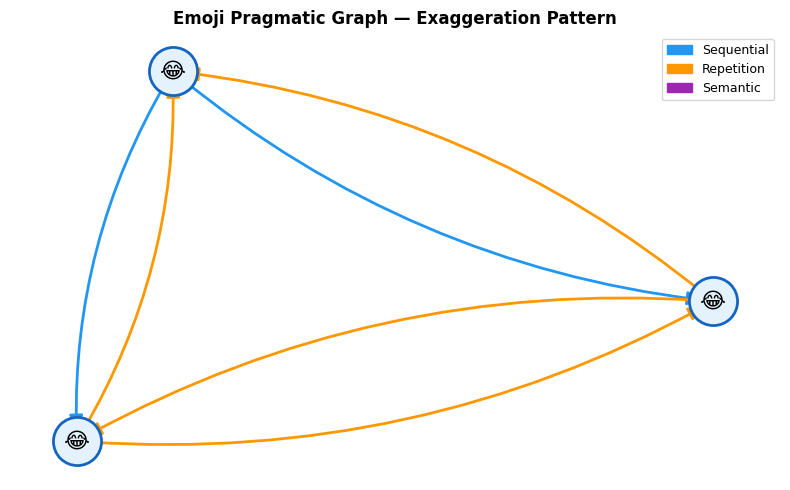

Graph visualization saved: /content/drive/MyDrive/EPGT_Research/outputs/figures/sample_emoji_graph.png


In [11]:
# ============================================================
# CELL 5.2 — Visualisasi Graph (sample)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import torch

def visualize_emoji_graph(graph, emojis, title="Emoji Pragmatic Graph"):
    """Visualisasi graph G=(V,E,W) dengan NetworkX."""
    G        = nx.DiGraph()
    n_nodes  = graph.num_nodes

    # Tambah node dengan label emoji
    for i in range(n_nodes):
        label = emojis[i] if i < len(emojis) else str(i)
        G.add_node(i, label=label)

    # Tambah edge dengan type
    edge_index  = graph.edge_index.numpy()
    edge_weights= graph.edge_weight.numpy()
    edge_types  = graph.edge_type.numpy()

    EDGE_COLORS = {0: "#2196F3", 1: "#FF9800", 2: "#9C27B0"}
    EDGE_LABELS = {0: "Sequential", 1: "Repetition", 2: "Semantic"}

    edge_color_list = []
    for i in range(edge_index.shape[1]):
        src, dst  = edge_index[0, i], edge_index[1, i]
        etype     = edge_types[i]
        G.add_edge(src, dst, weight=edge_weights[i], etype=etype)
        edge_color_list.append(EDGE_COLORS.get(etype, "gray"))

    fig, ax  = plt.subplots(figsize=(8, 5))
    pos      = nx.spring_layout(G, seed=42, k=2)
    labels   = {i: G.nodes[i].get("label", str(i)) for i in G.nodes}

    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color="#E3F2FD",
                           edgecolors="#1565C0", linewidths=2, ax=ax)
    nx.draw_networkx_labels(G, pos, labels, font_size=16, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_color_list,
                           arrows=True, arrowsize=20,
                           connectionstyle="arc3,rad=0.15",
                           width=2, ax=ax)

    # Legend
    patches = [
        mpatches.Patch(color=EDGE_COLORS[0], label="Sequential"),
        mpatches.Patch(color=EDGE_COLORS[1], label="Repetition"),
        mpatches.Patch(color=EDGE_COLORS[2], label="Semantic"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()

    fig_path = DRIVE_ROOT / "outputs/figures/sample_emoji_graph.png"
    plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Graph visualization saved: {fig_path}")

# Test dengan sample yang punya banyak emoji
multi_emoji_text = "wkwk lucu parah 😂😂😂 receh abis"
sample2          = preprocessor.normalizer.process(multi_emoji_text)
graph2           = builder.build_graph(
    emojis           = sample2["emoji_list"],
    positions        = sample2["emoji_positions"],
    repetition_flags = sample2["repetition_flags"],
    label_intensity  = 2,
    label_sarcasm    = 0,
    label_emoji_role = 1,  # Exaggeration
)

print(f"Sample: '{multi_emoji_text}'")
print(f"Emojis: {sample2['emoji_list']}")
visualize_emoji_graph(
    graph2,
    sample2["emoji_list"],
    title=f"Emoji Pragmatic Graph — Exaggeration Pattern",
)

In [12]:
# ============================================================
# CELL 5.3 — Batch Graph Construction: Train / Val / Test
# ============================================================

import pickle
import time

graph_dir = DRIVE_ROOT / "data/features/graph_objects"
graph_dir.mkdir(parents=True, exist_ok=True)

graph_splits = {}

for split_name, df_proc in processed_splits.items():
    print(f"\n{'='*50}")
    print(f"Building graphs [{split_name}] — {len(df_proc):,} samples")
    print(f"{'='*50}")

    t0     = time.time()
    graphs = builder.build_batch(df_proc, ablation_mode=None, show_progress=True)
    elapsed= time.time() - t0

    # Simpan ke Drive
    save_path = graph_dir / f"{split_name}_graphs.pkl"
    with open(save_path, "wb") as f:
        pickle.dump(graphs, f)

    graph_splits[split_name] = graphs

    # Stats
    n_nodes_list = [g.num_nodes for g in graphs]
    n_edges_list = [g.edge_index.shape[1] for g in graphs]

    print(f"Done in {elapsed:.1f}s")
    print(f"  Graphs saved    : {len(graphs):,}")
    print(f"  Avg nodes/graph : {sum(n_nodes_list)/len(n_nodes_list):.2f}")
    print(f"  Avg edges/graph : {sum(n_edges_list)/len(n_edges_list):.2f}")
    print(f"  Saved to        : {save_path}")

print(f"\nAll graph objects saved to: {graph_dir}")


Building graphs [train] — 56 samples


Building graphs:   0%|          | 0/56 [00:00<?, ?it/s]

Done in 0.1s
  Graphs saved    : 56
  Avg nodes/graph : 1.73
  Avg edges/graph : 2.09
  Saved to        : /content/drive/MyDrive/EPGT_Research/data/features/graph_objects/train_graphs.pkl

Building graphs [val] — 12 samples


Building graphs:   0%|          | 0/12 [00:00<?, ?it/s]

Done in 0.0s
  Graphs saved    : 12
  Avg nodes/graph : 1.58
  Avg edges/graph : 1.33
  Saved to        : /content/drive/MyDrive/EPGT_Research/data/features/graph_objects/val_graphs.pkl

Building graphs [test] — 12 samples


Building graphs:   0%|          | 0/12 [00:00<?, ?it/s]

Done in 0.0s
  Graphs saved    : 12
  Avg nodes/graph : 1.58
  Avg edges/graph : 2.08
  Saved to        : /content/drive/MyDrive/EPGT_Research/data/features/graph_objects/test_graphs.pkl

All graph objects saved to: /content/drive/MyDrive/EPGT_Research/data/features/graph_objects


In [13]:
# ============================================================
# CELL 5.4 — Verifikasi Graph Objects
# ============================================================

import pickle
from torch_geometric.data import Batch

print("Graph Object Verification:")
print("=" * 55)

for split_name in ["train", "val", "test"]:
    graph_path = DRIVE_ROOT / f"data/features/graph_objects/{split_name}_graphs.pkl"

    with open(graph_path, "rb") as f:
        graphs = pickle.load(f)

    # Cek graph pertama
    g0 = graphs[0]

    # Test batching (dibutuhkan saat training)
    batch = Batch.from_data_list(graphs[:4])

    print(f"\n[{split_name.upper()}]")
    print(f"  Total graphs          : {len(graphs):,}")
    print(f"  Sample graph[0]:")
    print(f"    x.shape             : {g0.x.shape}")
    print(f"    edge_index.shape    : {g0.edge_index.shape}")
    print(f"    edge_types present  : {g0.edge_type.unique().tolist()}")
    print(f"    y_intensity         : {g0.y_intensity.item()}")
    print(f"    y_sarcasm           : {g0.y_sarcasm.item()}")
    print(f"    y_role              : {g0.y_role.item()}")
    print(f"  Batch test (n=4):")
    print(f"    batch.x.shape       : {batch.x.shape}")
    print(f"    batch.batch.shape   : {batch.batch.shape}")

print("\nAll graph objects verified.")

Graph Object Verification:

[TRAIN]
  Total graphs          : 56
  Sample graph[0]:
    x.shape             : torch.Size([2, 203])
    edge_index.shape    : torch.Size([2, 1])
    edge_types present  : [0]
    y_intensity         : 2
    y_sarcasm           : 0
    y_role              : 0
  Batch test (n=4):
    batch.x.shape       : torch.Size([7, 203])
    batch.batch.shape   : torch.Size([7])

[VAL]
  Total graphs          : 12
  Sample graph[0]:
    x.shape             : torch.Size([1, 203])
    edge_index.shape    : torch.Size([2, 1])
    edge_types present  : [0]
    y_intensity         : 2
    y_sarcasm           : 1
    y_role              : 2
  Batch test (n=4):
    batch.x.shape       : torch.Size([6, 203])
    batch.batch.shape   : torch.Size([6])

[TEST]
  Total graphs          : 12
  Sample graph[0]:
    x.shape             : torch.Size([2, 203])
    edge_index.shape    : torch.Size([2, 1])
    edge_types present  : [0]
    y_intensity         : 0
    y_sarcasm           :

---
## BAGIAN 6 — NB03 COMPLETION REPORT

In [14]:
# ============================================================
# CELL 6.1 — NB03 Completion Report
# ============================================================

import pickle
from pathlib import Path

print("=" * 60)
print("NB03 COMPLETION REPORT")
print("EPGT Research — Preprocessing & Emoji Graph Construction")
print("=" * 60)

print("\n[1] SOURCE FILES")
src_files = [
    "src/data/preprocessor.py",
    "src/features/emoji_graph.py",
]
for f in src_files:
    p      = DRIVE_ROOT / f
    exists = p.exists()
    size   = f"{p.stat().st_size:,} bytes" if exists else ""
    print(f"  {'OK' if exists else 'MISSING':>7}  {f}  {size}")

print("\n[2] PROCESSED SPLITS")
for split in ["train", "val", "test"]:
    p = DRIVE_ROOT / f"data/processed/{split}_processed.csv"
    if p.exists():
        import pandas as pd
        n = len(pd.read_csv(p))
        print(f"  OK  {split}_processed.csv : {n:,} samples")
    else:
        print(f"  MISSING  {split}_processed.csv")

print("\n[3] GRAPH OBJECTS")
for split in ["train", "val", "test"]:
    p = DRIVE_ROOT / f"data/features/graph_objects/{split}_graphs.pkl"
    if p.exists():
        with open(p, "rb") as f:
            graphs = pickle.load(f)
        g0 = graphs[0]
        print(f"  OK  {split}_graphs.pkl : {len(graphs):,} graphs | "
              f"node_dim={g0.x.shape[1]} | edges/graph={g0.edge_index.shape[1]}")
    else:
        print(f"  MISSING  {split}_graphs.pkl")

print("\n[4] BLUEPRINT COMPLIANCE")
print(f"  Node feature dim  : {test_graph.x.shape[1]} (expected 203) {'OK' if test_graph.x.shape[1]==203 else 'FAIL'}")
print(f"  Edge types        : Sequential(0), Repetition(1), Semantic(2)")
print(f"  Tokenizer         : max_length=128, padding=max_length")
print(f"  Ablation support  : ablation_mode=no_position (ABL-4) ready")

print("\n[5] NEXT STEP")
print("  → NB04: Implementasi Arsitektur Model EPGT")
print("    TextSemanticEncoder + EmojiGraphEncoder (GAT)")
print("    + PragmaticFusionLayer + MTLClassificationHead")
print("\n" + "=" * 60)

NB03 COMPLETION REPORT
EPGT Research — Preprocessing & Emoji Graph Construction

[1] SOURCE FILES
       OK  src/data/preprocessor.py  11,190 bytes
       OK  src/features/emoji_graph.py  15,600 bytes

[2] PROCESSED SPLITS
  OK  train_processed.csv : 56 samples
  OK  val_processed.csv : 12 samples
  OK  test_processed.csv : 12 samples

[3] GRAPH OBJECTS
  OK  train_graphs.pkl : 56 graphs | node_dim=203 | edges/graph=1
  OK  val_graphs.pkl : 12 graphs | node_dim=203 | edges/graph=1
  OK  test_graphs.pkl : 12 graphs | node_dim=203 | edges/graph=1

[4] BLUEPRINT COMPLIANCE
  Node feature dim  : 203 (expected 203) OK
  Edge types        : Sequential(0), Repetition(1), Semantic(2)
  Tokenizer         : max_length=128, padding=max_length
  Ablation support  : ablation_mode=no_position (ABL-4) ready

[5] NEXT STEP
  → NB04: Implementasi Arsitektur Model EPGT
    TextSemanticEncoder + EmojiGraphEncoder (GAT)
    + PragmaticFusionLayer + MTLClassificationHead

